In [2]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()


  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`


In [3]:
using Revise
using Statistics
using CairoMakie
includet("analysis.jl")


In [4]:
function fig_path(fig_name::String)
        path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        #"/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

fig_path (generic function with 1 method)

In [5]:
colors = [
                Colors.colorant"#F1C21B",  # IBM Yellow
                Colors.colorant"#D12771",  # IBM Magenta
                Colors.colorant"#009D9A",  # IBM Teal
                Colors.colorant"#0F62FE",  # IBM Blue
                Colors.colorant"#6F6F6F",  # IBM Gray
                Colors.colorant"#FA4D56",  # IBM Red
                Colors.colorant"#24A148",  # IBM Green
        ]

# Link-Degree Skew vs Size for Manifoldlike Simply Connected Datasets

This notebook loads all available `manifoldlike_simply_connected_<size>_10000` statistics files,
computes the skew of the link-degree distribution for each sample, aggregates those skews with
`aggregate_hist_moment`, and plots the mean skew with asymmetric error bars as a function of size.

In [6]:
analysis_root_man_2 = "/Volumes/Causal Set Silo/causal_sets/analysis/link_degree_only"

function manifoldlike_size_path_pairs_2(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^manifoldlike_simply_connected_link_degree_(\d+)_1000$", name)
        msm = match(r"^manifoldlike_simply_connected_link_degree_(\d+)_100$", name)
        isnothing(m) && isnothing(msm) && continue

        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        ispow2(size) || continue
        size < 1024 && continue

        path = joinpath(root, name, "statistics.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end


size_path_pairs_man_2 = manifoldlike_size_path_pairs_2(analysis_root_man_2)
sizes_man_2 = first.(size_path_pairs_man_2)
paths_man_2 = last.(size_path_pairs_man_2)

sizes_man_2

7-element Vector{Int64}:
  1024
  2048
  4096
  8192
 16384
 32768
 65536

In [7]:
degree_hists_man_2 = CausalSetZoology.load_histograms_from_paths(paths_man_2, :degree_hist_link)

7-element Vector{Any}:
 [Dict(5 => 19, 16 => 38, 20 => 5, 7 => 75, 12 => 101, 8 => 105, 17 => 25, 23 => 1, 19 => 8, 4 => 9…), Dict(5 => 38, 16 => 30, 20 => 5, 12 => 106, 24 => 1, 8 => 117, 17 => 24, 19 => 9, 22 => 1, 6 => 52…), Dict(5 => 29, 16 => 40, 20 => 3, 7 => 79, 12 => 105, 8 => 83, 17 => 14, 19 => 8, 22 => 1, 4 => 13…), Dict(5 => 34, 16 => 42, 20 => 6, 7 => 72, 12 => 94, 8 => 85, 17 => 17, 23 => 2, 19 => 7, 4 => 9…), Dict(5 => 27, 16 => 36, 20 => 7, 12 => 99, 24 => 1, 8 => 104, 17 => 21, 19 => 10, 22 => 2, 6 => 28…), Dict(5 => 39, 16 => 31, 20 => 4, 7 => 62, 12 => 131, 8 => 98, 17 => 17, 1 => 1, 19 => 12, 4 => 27…), Dict(5 => 55, 16 => 20, 20 => 3, 12 => 86, 8 => 112, 17 => 16, 1 => 1, 19 => 3, 22 => 2, 23 => 1…), Dict(5 => 37, 16 => 21, 20 => 1, 12 => 105, 8 => 106, 17 => 15, 1 => 1, 19 => 5, 22 => 1, 6 => 49…), Dict(5 => 38, 16 => 33, 20 => 5, 12 => 94, 24 => 1, 8 => 90, 17 => 32, 23 => 2, 19 => 9, 22 => 2…), Dict(5 => 30, 16 => 36, 20 => 1, 7 => 82, 12 => 116, 8 => 98, 17 => 

In [8]:
skew_stats_man_2 = [
    CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_skew)
    for hists in degree_hists_man_2
]

skew_means_man_2 = getfield.(skew_stats_man_2, :mean)
skew_stds_man_2 = getfield.(skew_stats_man_2, :std)
skew_lows_man_2 = getfield.(skew_stats_man_2, :std_lo)
skew_highs_man_2 = getfield.(skew_stats_man_2, :std_hi)

all(skew_means_man_2 .> 0) || error("Log-log plot requires positive skew means, but at least one mean skew is non-positive.")

[(; size = sizes_man_2[i], mean = skew_means_man_2[i], std = skew_stds_man_2[i], std_lo = skew_lows_man_2[i], std_hi = skew_highs_man_2[i]) for i in eachindex(sizes_man_2)]

7-element Vector{@NamedTuple{size::Int64, mean::Float64, std::Float64, std_lo::Float64, std_hi::Float64}}:
 (size = 1024, mean = 0.2800662334430917, std = 0.10480409045058729, std_lo = 0.09044754221776014, std_hi = 0.09667691630788872)
 (size = 2048, mean = 0.24650175532852178, std = 0.08052310142539658, std_lo = 0.06435300005591091, std_hi = 0.07636133945116394)
 (size = 4096, mean = 0.21729534244664858, std = 0.056565577047086056, std_lo = 0.04663002016151288, std_hi = 0.05147719504857168)
 (size = 8192, mean = 0.19466747725026556, std = 0.04379085777913112, std_lo = 0.038027952709550505, std_hi = 0.038801520516973415)
 (size = 16384, mean = 0.1752258588290511, std = 0.033721990182766025, std_lo = 0.026181821843049374, std_hi = 0.027457049417094315)
 (size = 32768, mean = 0.16134480901978984, std = 0.026566795755070493, std_lo = 0.01725217451842001, std_hi = 0.021187507440722703)
 (size = 65536, mean = 0.14989270039517522, std = 0.02278573415170145, std_lo = 0.01427082923322498, std_

In [9]:
decay_exponent_man_2 = (log(skew_means_man_2[end]) - log(skew_means_man_2[1])) / (log(sizes_man_2[end]) - log(sizes_man_2[1]))

-0.15030632101249145

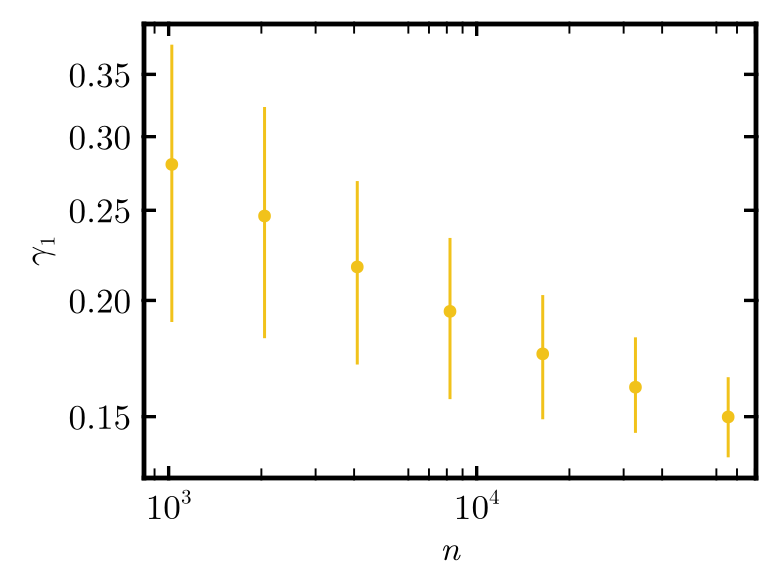

In [10]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
#    title = "Manifoldlike simply connected link-degree skew",
    xscale = log10,
    yscale = log10,
    yticks = [0.15, 0.2, 0.25, .3, .35, .4, .5],
    xticks = ([1e3,1e4], [L"10^3", L"10^4"])
)

#lines!(ax, sizes_man_2,0.78 .* sizes_man_2 .^ decay_exponent_man_2, color = colors[2])
errorbars!(ax, sizes_man_2, skew_means_man_2, skew_lows_man_2, skew_highs_man_2,)
scatter!(ax, sizes_man_2, skew_means_man_2; marker = :circle)

save(fig_path("graph_observables/degree_skew_size_scaling.pdf"), fig)

fig

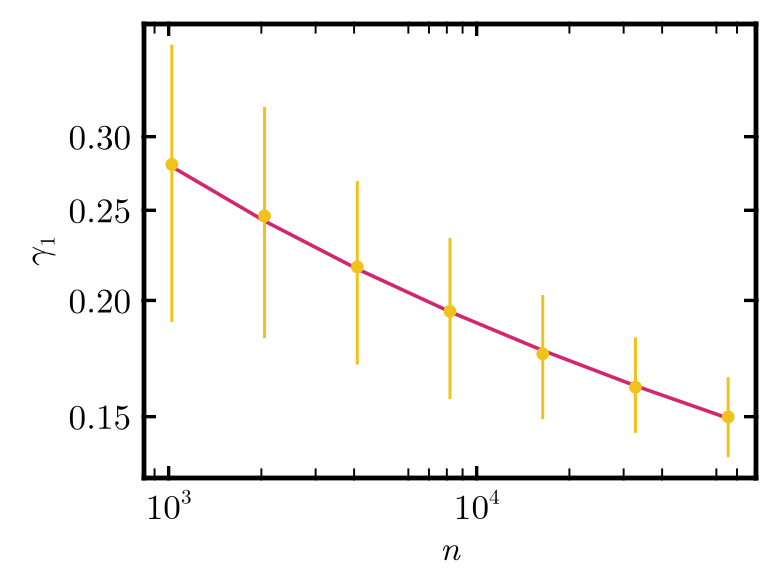

In [100]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
#    title = "Manifoldlike simply connected link-degree skew",
    xscale = log10,
    yscale = log10,
    yticks = [0.15, 0.2, 0.25, .3, .4, .5],
    xticks = ([1e3,1e4], [L"10^3", L"10^4"])
)

lines!(ax, sizes_man_2, 1.34 ./ log.(0.12*sizes_man_2), color = colors[2])
errorbars!(ax, sizes_man_2, skew_means_man_2, skew_lows_man_2, skew_highs_man_2,)
scatter!(ax, sizes_man_2, skew_means_man_2; marker = :circle)

save(fig_path("graph_observables/degree_skew_size_scaling.pdf"), fig)

fig

# Link-Degree Skew vs Size for Minkowski sprinkling Datasets

In [11]:
analysis_root = "/Volumes/Causal Set Silo/causal_sets/analysis/link_degree_only/"

function minkowski_size_path_pairs(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^minkowski_sprinkling_link_degree_(\d+)_1000$", name)
        msm = match(r"^minkowski_sprinkling_link_degree_(\d+)_100$", name)
        isnothing(m) && isnothing(msm) && continue
        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        path = joinpath(root, name, "statistics.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end

size_path_pairs_mink = minkowski_size_path_pairs(analysis_root)
sizes_mink = first.(size_path_pairs_mink)
paths_mink = last.(size_path_pairs_mink)

sizes_mink

12-element Vector{Int64}:
    1024
    2048
    4096
    8192
   16384
   32768
   65536
  131072
  262144
  262144
  524288
 1048576

In [12]:
degree_hists_mink = CausalSetZoology.load_histograms_from_paths(paths_mink, :degree_hist_link)

12-element Vector{Any}:
 [Dict(5 => 12, 16 => 40, 20 => 1, 7 => 62, 12 => 122, 8 => 75, 17 => 35, 19 => 12, 22 => 1, 4 => 7…), Dict(5 => 21, 16 => 27, 7 => 73, 12 => 113, 8 => 99, 17 => 24, 19 => 2, 4 => 2, 6 => 39, 13 => 88…), Dict(5 => 23, 16 => 40, 20 => 2, 7 => 75, 12 => 119, 24 => 1, 8 => 84, 17 => 19, 19 => 3, 4 => 4…), Dict(5 => 26, 16 => 30, 20 => 1, 12 => 112, 8 => 94, 17 => 17, 1 => 1, 19 => 2, 22 => 1, 6 => 39…), Dict(5 => 9, 16 => 27, 20 => 4, 7 => 57, 12 => 123, 8 => 83, 17 => 19, 23 => 1, 19 => 11, 22 => 1…), Dict(5 => 13, 16 => 34, 20 => 3, 7 => 65, 12 => 123, 8 => 84, 17 => 16, 19 => 5, 4 => 1, 6 => 31…), Dict(5 => 14, 16 => 31, 20 => 2, 7 => 70, 12 => 125, 8 => 97, 17 => 22, 19 => 4, 4 => 6, 6 => 21…), Dict(5 => 16, 16 => 42, 20 => 2, 7 => 61, 12 => 133, 8 => 92, 17 => 18, 19 => 7, 4 => 6, 6 => 32…), Dict(5 => 14, 16 => 43, 20 => 4, 7 => 68, 12 => 137, 8 => 82, 17 => 24, 23 => 1, 19 => 6, 22 => 1…), Dict(5 => 22, 16 => 25, 20 => 1, 7 => 56, 12 => 134, 8 => 101, 17 => 1

In [13]:
skew_stats_mink = [
    CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_skew)
    for hists in degree_hists_mink
]

skew_means_mink = getfield.(skew_stats_mink, :mean)
skew_stds_mink = getfield.(skew_stats_mink, :std)
skew_lows_mink = getfield.(skew_stats_mink, :std_lo)
skew_highs_mink = getfield.(skew_stats_mink, :std_hi)

all(skew_means_mink .> 0) || error("Log-log plot requires positive skew means, but at least one mean skew is non-positive.")

[(; size = sizes_mink[i], mean = skew_means_mink[i], std = skew_stds_mink[i], std_lo = skew_lows_mink[i], std_hi = skew_highs_mink[i]) for i in eachindex(sizes_mink)]

12-element Vector{@NamedTuple{size::Int64, mean::Float64, std::Float64, std_lo::Float64, std_hi::Float64}}:
 (size = 1024, mean = 0.25517991100568693, std = 0.0843177972911055, std_lo = 0.08373731679614213, std_hi = 0.08465021211602286)
 (size = 2048, mean = 0.24951461144573703, std = 0.06142209517880349, std_lo = 0.05969304397255251, std_hi = 0.061561912293536886)
 (size = 4096, mean = 0.23997753972534858, std = 0.040885628544118, std_lo = 0.03762949239911942, std_hi = 0.043797342518013704)
 (size = 8192, mean = 0.2319051965700888, std = 0.029075635995191945, std_lo = 0.027087876222033735, std_hi = 0.028795706643499064)
 (size = 16384, mean = 0.22516858703624745, std = 0.02155592296243637, std_lo = 0.022104518234578957, std_hi = 0.020979427888681595)
 (size = 32768, mean = 0.21761725482025804, std = 0.015278761197281523, std_lo = 0.01503798713253826, std_hi = 0.01559572671420098)
 (size = 65536, mean = 0.21032419987331338, std = 0.010193513746588443, std_lo = 0.010537397884860106, std

In [14]:
decay_exponent_mink = (log(skew_means_mink[end]) - log(skew_means_mink[1])) / (log(sizes_mink[end]) - log(sizes_mink[1]))

-0.04275886402461892

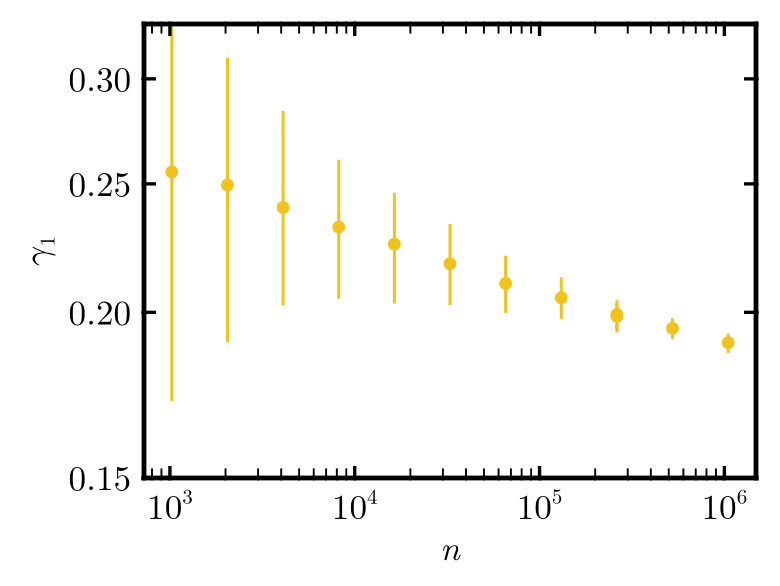

In [16]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
#    title = "Manifoldlike simply connected link-degree skew",
    xscale = log10,
    yscale = log10,
    yticks = [0.15, 0.2, 0.25, .3, .4, .5],
    xticks = ([1e3, 1e4, 1e5, 1e6], [L"10^3", L"10^4", L"10^5", L"10^6"])
)

ylims!(ax, 0.15, 0.33)

#lines!(ax, sizes_mink,0.35 .* sizes_mink .^ decay_exponent_mink, color = colors[2])
errorbars!(ax, sizes_mink, skew_means_mink, min.(skew_means_mink.-1e-6, skew_lows_mink), skew_highs_mink)
scatter!(ax, sizes_mink, skew_means_mink; marker = :circle)

save(fig_path("graph_observables/degree_skew_size_scaling_Minkowski.pdf"), fig)

fig

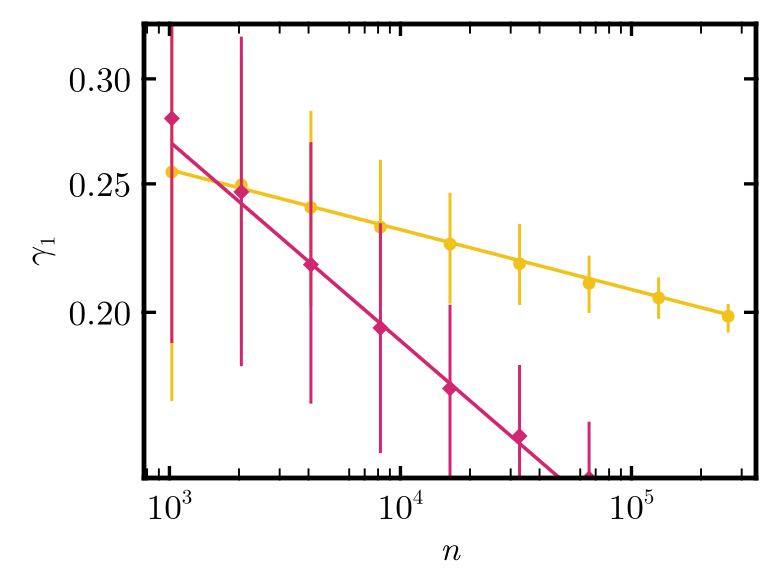

In [92]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
#    title = "Manifoldlike simply connected link-degree skew",
    xscale = log10,
    yscale = log10,
    yticks = [0.2, 0.25, 0.3],
    xticks = ([1e3, 1e4, 1e5], [L"10^3", L"10^4", L"10^5"])
)

ylims!(ax, 0.15, 0.33)

lines!(ax, sizes_mink,0.35 .* sizes_mink .^ decay_exponent_mink, color = colors[1])
errorbars!(ax, sizes_mink, skew_means_mink, min.(skew_means_mink.-1e-6, skew_lows_mink), skew_highs_mink)
scatter!(ax, sizes_mink, skew_means_mink; marker = :circle)

lines!(ax, sizes_man_2,0.76 .* sizes_man_2 .^ decay_exponent_man_2, color = colors[2])
errorbars!(ax, sizes_man_2, skew_means_man_2, min.(skew_means_man_2.-1e-6, skew_lows_man_2), skew_highs_man_2, color = colors[2])
scatter!(ax, sizes_man_2, skew_means_man_2; marker = :diamond, color = colors[2])


save(fig_path("graph_observables/degree_skew_size_scaling_combined.pdf"), fig)

fig